# LoanTap Personal Loan — Credit Risk Prediction

---

## Business Context

**LoanTap** is an online fintech platform that provides customised personal loans to millennial borrowers. Unlike traditional lenders, LoanTap offers flexible repayment options to borrowers who may not qualify at conventional banks.

The core risk for any lender is disbursing a loan to a borrower who **will not repay it**. These loans become **Non-Performing Assets (NPAs)** — a direct financial loss.

---

## Problem Statement

> **Can we predict, at the time of loan application, whether a borrower will fully repay or default?**

| Target Value | Meaning |
|---|---|
| `0` | Fully Paid — borrower repaid the loan in full |
| `1` | Charged Off — borrower defaulted |

---

## Project Flow

**Data Inspection → Cleaning → Feature Engineering → EDA → Encoding → Feature Selection → VIF → Train/Test Split → Scaling → Baseline Model → SMOTE → SMOTE Model → Evaluation → Threshold Analysis → Business Recommendations**


---
## Section 1: Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
df = pd.read_csv('/Users/vishwashpatidar/Downloads/logistic_regression.csv')
print(f"Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Dataset loaded: 396,030 rows x 27 columns


,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


---
## Section 2: Initial Data Inspection

Before making any changes, we do a quick scan to understand the dataset:
- Dimensions (rows × columns)
- Data types and non-null counts
- Missing values
- Target variable distribution

In [3]:
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print()
df.info()

Shape: 396,030 rows x 27 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title             

In [4]:
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [5]:
# Target variable
print("Loan Status distribution:")
print(df['loan_status'].value_counts())
print()
print("As percentages:")
print((df['loan_status'].value_counts(normalize=True) * 100).round(2))

Loan Status distribution:
loan_status
Fully Paid     318357
Charged Off     77673
Name: count, dtype: int64

As percentages:
loan_status
Fully Paid     80.39
Charged Off    19.61
Name: proportion, dtype: float64


**Key Observation:** The dataset is imbalanced — roughly 80% Fully Paid and 20% Charged Off. A naive model that predicts "Fully Paid" every time would get ~80% accuracy but miss almost all actual defaults. We will address this using **SMOTE** later.

In [6]:
# High-cardinality columns that cannot be used as features
print("High-cardinality text columns (will be dropped):")
for col in ['emp_title', 'title', 'address']:
    print(f"  {col}: {df[col].nunique():,} unique values")

print()
print("Categorical columns we will keep:")
for col in ['grade', 'sub_grade', 'home_ownership', 'verification_status',
            'application_type', 'initial_list_status', 'purpose']:
    print(f"  {col}: {df[col].nunique()} unique values")

High-cardinality text columns (will be dropped):
  emp_title: 173,105 unique values
  title: 48,816 unique values
  address: 393,700 unique values

Categorical columns we will keep:
  grade: 7 unique values
  sub_grade: 35 unique values
  home_ownership: 6 unique values
  verification_status: 3 unique values
  application_type: 3 unique values
  initial_list_status: 2 unique values
  purpose: 14 unique values


In [7]:
# Missing values overview
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print("Columns with missing values:")
display(missing_df)

Columns with missing values:


,Missing Count,Missing %
mort_acc,37795,9.54
emp_title,22927,5.79
emp_length,18301,4.62
title,1756,0.44
pub_rec_bankruptcies,535,0.14
revol_util,276,0.07


---
## Section 3: Data Cleaning

### 3.1 Drop Irrelevant Columns

| Column | Reason |
|---|---|
| `address` | Free text, high cardinality, PII |
| `emp_title` | 173k+ unique job titles — impossible to encode meaningfully |
| `title` | Duplicate of `purpose` in free-text form |

In [8]:
df_new = df.drop(columns=['address', 'emp_title', 'title'])
print(f"Shape after dropping irrelevant columns: {df_new.shape}")

Shape after dropping irrelevant columns: (396030, 24)


### 3.2 Check for Duplicates

In [9]:
n_duplicates = df_new.duplicated().sum()
print(f"Duplicate rows: {n_duplicates}")

Duplicate rows: 0


### 3.3 Handle Missing Values

Four columns have missing values. Each requires a different strategy based on its distribution.

In [10]:
cols_with_missing = ['emp_length', 'revol_util', 'mort_acc', 'pub_rec_bankruptcies']

print(f"{'Column':<28} {'Count':>8} {'Percent':>10}")
print("-" * 48)
for col in cols_with_missing:
    count = df_new[col].isnull().sum()
    pct = count / len(df_new) * 100
    print(f"{col:<28} {count:>8,} {pct:>9.2f}%")

Column                          Count    Percent
------------------------------------------------
emp_length                     18,301      4.62%
revol_util                        276      0.07%
mort_acc                       37,795      9.54%
pub_rec_bankruptcies              535      0.14%


#### 3.3a `mort_acc` — Impute Using Home Ownership Group Medians

`mort_acc` has the highest missing rate (~9.5%). Borrowers with a MORTGAGE tend to have more mortgage accounts than those who RENT. We impute using the **median within each home ownership group** — this is more precise than a global median.

In [11]:
# Compute group medians
mort_acc_medians = df_new.groupby('home_ownership')['mort_acc'].median()
print("Median mort_acc by home_ownership:")
print(mort_acc_medians)

Median mort_acc by home_ownership:
home_ownership
ANY         2.0
MORTGAGE    2.0
NONE        2.0
OTHER       1.0
OWN         1.0
RENT        0.0
Name: mort_acc, dtype: float64


In [12]:
def fill_mort_acc(home_ownership, mort_acc):
    if np.isnan(mort_acc):
        return mort_acc_medians[home_ownership]
    else:
        return mort_acc

df_new['mort_acc'] = df_new.apply(lambda x: fill_mort_acc(x['home_ownership'], x['mort_acc']), axis=1)
print(f"Missing values in mort_acc: {df_new['mort_acc'].isnull().sum()}")

Missing values in mort_acc: 0


#### 3.3b `emp_length` — Map to Ordinal Then Impute with Median

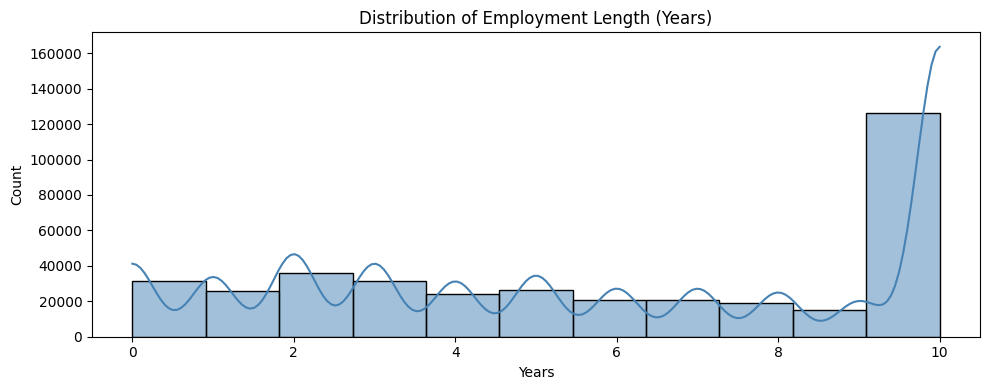

Median: 6.0


In [13]:
# Map string values to ordinal numbers
emp_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9,
    '10+ years': 10
}

df_new['emp_length'] = df_new['emp_length'].map(emp_map)

# Visualize distribution to confirm imputation strategy
plt.figure(figsize=(10, 4))
sns.histplot(df_new['emp_length'].dropna(), bins=11, kde=True, color='steelblue')
plt.title('Distribution of Employment Length (Years)')
plt.xlabel('Years')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Median: {df_new['emp_length'].median()}")

In [14]:
# Impute with median
median_emp = df_new['emp_length'].median()
df_new['emp_length'] = df_new['emp_length'].fillna(median_emp)
print(f"emp_length imputed with median: {median_emp:.0f}")
print(f"Missing values remaining: {df_new['emp_length'].isnull().sum()}")

emp_length imputed with median: 6
Missing values remaining: 0


#### 3.3c `revol_util` and `pub_rec_bankruptcies` — Impute with Median

Both have very few missing values (<0.15%) and are right-skewed, so median is appropriate.

In [15]:
for col in ['revol_util', 'pub_rec_bankruptcies']:
    median_val = df_new[col].median()
    df_new[col] = df_new[col].fillna(median_val)
    print(f"{col}: imputed with median {median_val:.2f} | Missing remaining: {df_new[col].isnull().sum()}")

print()
total_missing = df_new.isnull().sum().sum()
print(f"Total missing values after imputation: {total_missing}")

revol_util: imputed with median 54.80 | Missing remaining: 0
pub_rec_bankruptcies: imputed with median 0.00 | Missing remaining: 0

Total missing values after imputation: 0


---
## Section 4: Feature Engineering

### 4.1 Convert `term` to Numeric

In [16]:
# term is stored as ' 36 months' — we extract just the number
df_new['term'] = df_new['term'].apply(lambda x: int(x.split()[0]))
print("Unique values in term:", df_new['term'].unique())

Unique values in term: [36 60]


### 4.2 Create Binary Flags from Count Columns

`pub_rec`, `mort_acc`, and `pub_rec_bankruptcies` are count columns. For credit risk, what matters is **whether or not** these events occurred, not the exact count. We create binary flags.

In [17]:
flag_cols = {
    'pub_rec': 'pub_rec_flag',
    'mort_acc': 'mort_acc_flag',
    'pub_rec_bankruptcies': 'pub_rec_bankruptcies_flag'
}

for original_col, flag_col in flag_cols.items():
    df_new[flag_col] = (df_new[original_col] > 0).astype(int)

# Verify
display(df_new[['pub_rec', 'pub_rec_flag',
                'mort_acc', 'mort_acc_flag',
                'pub_rec_bankruptcies', 'pub_rec_bankruptcies_flag']].head())

print("\nFlag value counts:")
for flag_col in flag_cols.values():
    print(f"  {flag_col}: {df_new[flag_col].value_counts().to_dict()}")

,pub_rec,pub_rec_flag,mort_acc,mort_acc_flag,pub_rec_bankruptcies,pub_rec_bankruptcies_flag
0,0.0,0,0.0,0,0.0,0
1,0.0,0,3.0,1,0.0,0
2,0.0,0,0.0,0,0.0,0
3,0.0,0,0.0,0,0.0,0
4,0.0,0,1.0,1,0.0,0



Flag value counts:
  pub_rec_flag: {0: 338272, 1: 57758}
  mort_acc_flag: {1: 238147, 0: 157883}
  pub_rec_bankruptcies_flag: {0: 350915, 1: 45115}


In [18]:
# Drop the original count columns — the flags carry the information we need
df_new = df_new.drop(columns=['pub_rec', 'mort_acc', 'pub_rec_bankruptcies'])
print(f"Shape after dropping count columns: {df_new.shape}")

Shape after dropping count columns: (396030, 24)


### 4.3 Credit History Length (`credit_age_years`)

A longer credit history generally indicates financial stability. We calculate: `issue year − year of first credit line`.

In [19]:
df_new['issue_d'] = pd.to_datetime(df_new['issue_d'])
df_new['earliest_cr_line'] = pd.to_datetime(df_new['earliest_cr_line'])

df_new['credit_age_years'] = df_new['issue_d'].dt.year - df_new['earliest_cr_line'].dt.year

print(f"Credit age range: {df_new['credit_age_years'].min()} to {df_new['credit_age_years'].max()} years")
print(f"Mean credit age: {df_new['credit_age_years'].mean():.1f} years")

# Drop raw date columns
df_new.drop(columns=['issue_d', 'earliest_cr_line'], inplace=True)

Credit age range: 3 to 70 years
Mean credit age: 15.8 years


### 4.4 Ordinal Encode `sub_grade`

We encode `sub_grade` as an ordinal integer: A1=1, A2=2, ... G5=35. This preserves the natural risk ordering. We keep `sub_grade` and later drop `grade` because sub_grade is a finer version of grade (grade is fully captured by sub_grade).

In [20]:
sub_grades = sorted(df['sub_grade'].unique())
sub_grade_map = {val: i+1 for i, val in enumerate(sub_grades)}
df_new['sub_grade'] = df_new['sub_grade'].map(sub_grade_map)

print(f"sub_grade encoded: A1=1, A2=2 ... G5=35")
print(f"Range: {df_new['sub_grade'].min()} to {df_new['sub_grade'].max()}")
print(f"Missing values: {df_new['sub_grade'].isnull().sum()}")

sub_grade encoded: A1=1, A2=2 ... G5=35
Range: 1 to 35
Missing values: 0


---
## Section 5: Exploratory Data Analysis (EDA)

### 5.1 Target Variable — Class Imbalance

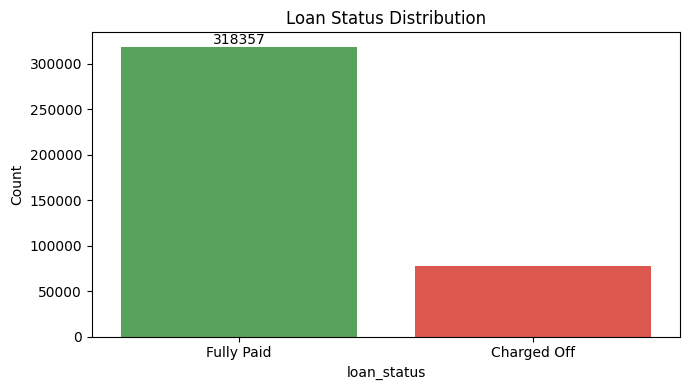

Fully Paid:  318,357 (80.4%)
Charged Off: 77,673 (19.6%)


In [21]:
counts = df_new['loan_status'].value_counts()
pcts = df_new['loan_status'].value_counts(normalize=True) * 100

plt.figure(figsize=(7, 4))
ax = sns.barplot(x=counts.index, y=counts.values,
                 palette={'Fully Paid': '#4CAF50', 'Charged Off': '#F44336'})
ax.bar_label(ax.containers[0], fmt='%d', fontsize=10)
plt.title('Loan Status Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Fully Paid:  {counts['Fully Paid']:,} ({pcts['Fully Paid']:.1f}%)")
print(f"Charged Off: {counts['Charged Off']:,} ({pcts['Charged Off']:.1f}%)")

**Observation:** ~80% Fully Paid, ~20% Charged Off. A model that predicts "Fully Paid" for everyone would get 80% accuracy but zero recall on actual defaults — useless for credit risk. This is why we need SMOTE.

### 5.2 Default Rate by Loan Grade

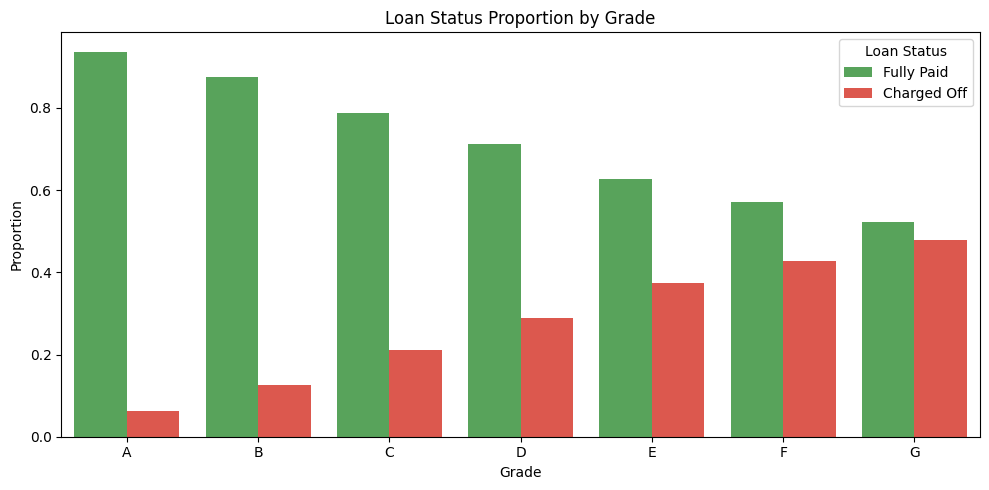

In [22]:
grade_status = df_new.groupby('grade')['loan_status'].value_counts(normalize=True).rename('pct').reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='grade', y='pct', hue='loan_status',
            data=grade_status,
            order=sorted(df_new['grade'].unique()),
            palette={'Fully Paid': '#4CAF50', 'Charged Off': '#F44336'})
plt.title('Loan Status Proportion by Grade')
plt.ylabel('Proportion')
plt.xlabel('Grade')
plt.legend(title='Loan Status')
plt.tight_layout()
plt.show()

**Observation:** Default rate increases clearly from Grade A → Grade G. This confirms that `sub_grade` (a finer version of grade) will be a strong predictor.

### 5.3 Annual Income and DTI by Loan Status

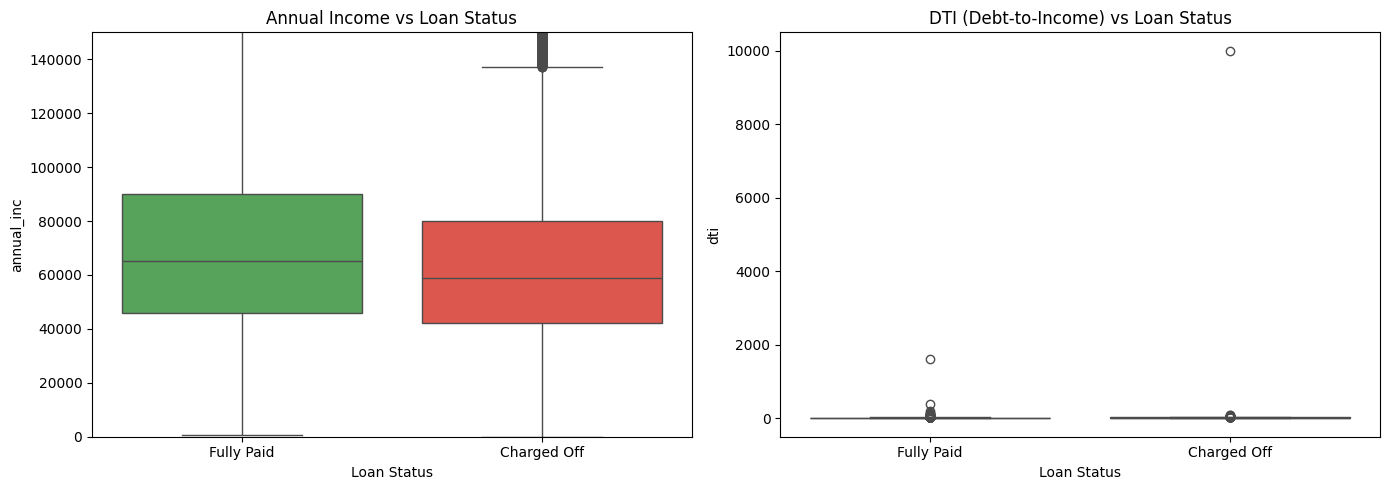

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(x='loan_status', y='annual_inc', data=df_new, ax=axes[0],
            palette={'Fully Paid': '#4CAF50', 'Charged Off': '#F44336'})
axes[0].set_ylim(0, df_new['annual_inc'].quantile(0.95))
axes[0].set_title('Annual Income vs Loan Status')
axes[0].set_xlabel('Loan Status')

sns.boxplot(x='loan_status', y='dti', data=df_new, ax=axes[1],
            palette={'Fully Paid': '#4CAF50', 'Charged Off': '#F44336'})
axes[1].set_title('DTI (Debt-to-Income) vs Loan Status')
axes[1].set_xlabel('Loan Status')

plt.tight_layout()
plt.show()

**Observations:**
- Borrowers who fully paid tend to have slightly higher income
- Charged-off borrowers have higher DTI — they carried more debt relative to income

### 5.4 Charge-Off Rate by Loan Purpose

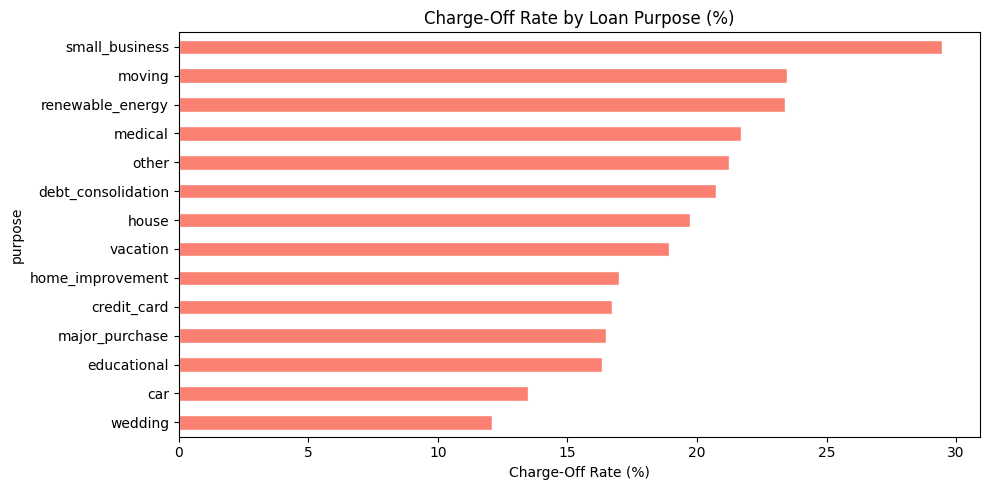

In [24]:
purpose_default_rate = (
    df_new.groupby('purpose')['loan_status']
    .apply(lambda x: (x == 'Charged Off').mean() * 100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 5))
purpose_default_rate.plot(kind='barh', color='salmon', edgecolor='white')
plt.title('Charge-Off Rate by Loan Purpose (%)')
plt.xlabel('Charge-Off Rate (%)')
plt.tight_layout()
plt.show()

**Observation:** Small business loans have the highest charge-off rate. This makes sense — small businesses carry higher failure risk.

### 5.5 Revolving Credit Utilisation

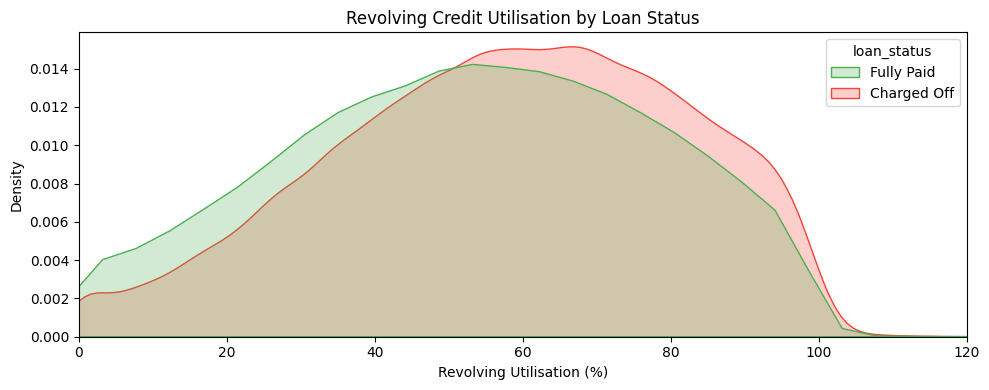

In [25]:
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df_new, x='revol_util', hue='loan_status',
            fill=True, common_norm=False,
            palette={'Fully Paid': '#4CAF50', 'Charged Off': '#F44336'})
plt.title('Revolving Credit Utilisation by Loan Status')
plt.xlabel('Revolving Utilisation (%)')
plt.xlim(0, 120)
plt.tight_layout()
plt.show()

**Observation:** Charged-off borrowers tend to have higher revolving utilisation. High utilisation (>70%) suggests the borrower is already financially stretched.

---
## Section 6: Outlier Treatment

Financial datasets naturally contain extreme values (very high-income borrowers, very large loans). Instead of deleting these rows, we use **IQR-based Winsorization** — capping values at the whisker boundaries.

This preserves all rows while limiting the influence of extreme values on the model.

In [26]:
# DTI extreme values
print("DTI extreme values:")
for t in [40, 50, 100]:
    count = (df_new['dti'] > t).sum()
    pct = count / len(df_new) * 100
    print(f"  DTI > {t}: {count:,} rows ({pct:.3f}%)")

DTI extreme values:
  DTI > 40: 296 rows (0.075%)
  DTI > 50: 35 rows (0.009%)
  DTI > 100: 8 rows (0.002%)


In [27]:
# Cap DTI
Q1 = df_new['dti'].quantile(0.25)
Q3 = df_new['dti'].quantile(0.75)
IQR = Q3 - Q1
lower_dti = Q1 - 1.5 * IQR
upper_dti = Q3 + 1.5 * IQR

df_new['dti'] = df_new['dti'].clip(lower_dti, upper_dti)
print(f"dti capped at: [{lower_dti:.2f}, {upper_dti:.2f}]")

dti capped at: [-6.27, 40.53]


In [28]:
# Cap remaining numeric columns
columns_to_cap = ['annual_inc', 'loan_amnt', 'installment', 'int_rate', 'revol_bal', 'revol_util']

print(f"{'Column':<20} {'Lower Whisker':>15} {'Upper Whisker':>15}")
print("-" * 52)
for col in columns_to_cap:
    Q1 = df_new[col].quantile(0.25)
    Q3 = df_new[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_new[col] = df_new[col].clip(lower, upper)
    print(f"{col:<20} {lower:>15.2f} {upper:>15.2f}")

Column                 Lower Whisker   Upper Whisker
----------------------------------------------------
annual_inc                 -22500.00       157500.00
loan_amnt                  -10000.00        38000.00
installment                  -225.12         1042.75
int_rate                        1.49           25.49
revol_bal                  -14367.50        40012.50
revol_util                    -19.60          128.40


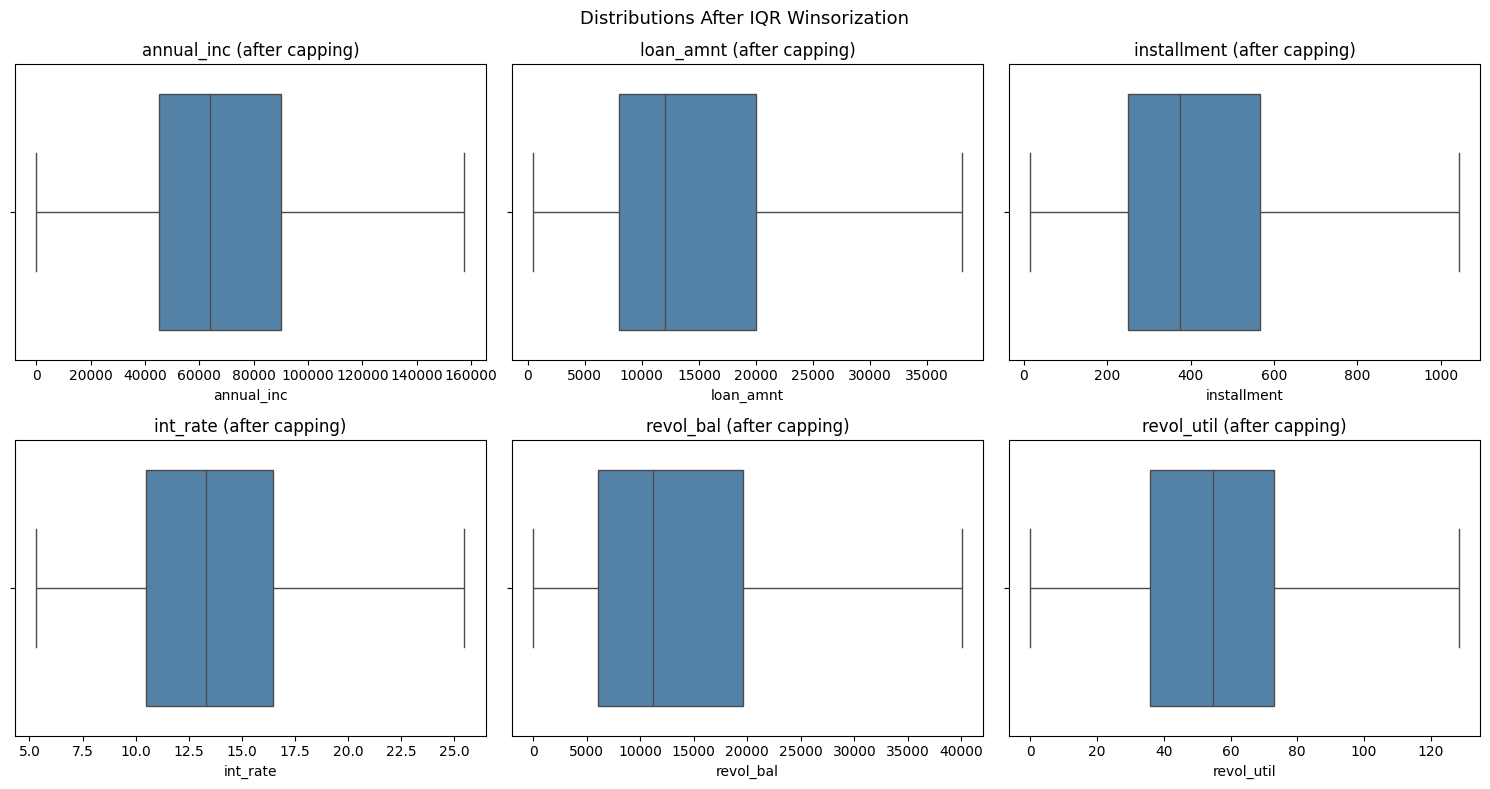

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(columns_to_cap):
    sns.boxplot(x=df_new[col], ax=axes[i // 3][i % 3], color='steelblue')
    axes[i // 3][i % 3].set_title(f'{col} (after capping)')
plt.suptitle('Distributions After IQR Winsorization', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 7: Categorical Encoding

### 7.1 One-Hot Encoding

We use `pd.get_dummies()` with `drop_first=True` to avoid the **dummy variable trap** (perfect multicollinearity when all dummy categories for a column sum to 1).

| Column | Reference Category Dropped |
|---|---|
| `home_ownership` | alphabetically first |
| `verification_status` | `Not Verified` |
| `purpose` | `car` |
| `application_type` | `DIRECT_PAY` |
| `initial_list_status` | `f` |

In [30]:
cols_to_encode = ['home_ownership', 'verification_status', 'purpose',
                  'application_type', 'initial_list_status']

df_new = pd.get_dummies(df_new, columns=cols_to_encode, drop_first=True, dtype=int)

print(f"Shape after one-hot encoding: {df_new.shape}")

Shape after one-hot encoding: (396030, 41)


### 7.2 Target Variable Encoding

**Encoding:** `Fully Paid` → `0` | `Charged Off` → `1`

Class 1 (Charged Off) is the minority positive class we want to detect.

In [31]:
df_new['loan_status'] = df_new['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

print("Target variable encoded:")
print(df_new['loan_status'].value_counts())
print("0 = Fully Paid | 1 = Charged Off")

Target variable encoded:
loan_status
0    318357
1     77673
Name: count, dtype: int64
0 = Fully Paid | 1 = Charged Off


---
## Section 8: Feature Selection

We remove features that are redundant, near-collinear, or already captured by other features.

| Feature Removed | Reason |
|---|---|
| `grade` | Sub_grade is a finer version — grade is redundant |
| `int_rate` | Directly set by sub_grade — near-perfect collinearity |
| `loan_amnt` | Strongly correlated with installment (r ≈ 0.95) — installment is more directly related to repayment burden |
| All `home_ownership_*` dummies | Overlap with `mort_acc_flag` (mortgage holders have more accounts); keeping both causes high VIF |
| `purpose_debt_consolidation` | ~47% of rows — dominant category causes severe collinearity with other purpose dummies |
| `application_type_INDIVIDUAL` | ~96% of rows — near-constant, causes very high VIF |
| `total_acc` | Strongly correlated with `open_acc` (r ≈ 0.7) — same information, open_acc is cleaner |

> Removing due to collinearity does not mean the feature is unimportant. It means another feature in the dataset already carries the same information.

In [32]:
# Verify the correlations we're using to justify removals
corr_loan_install = df_new[['loan_amnt', 'installment']].corr().loc['loan_amnt', 'installment']
corr_acc = df_new[['open_acc', 'total_acc']].corr().loc['open_acc', 'total_acc']

print(f"Correlation: loan_amnt vs installment = {corr_loan_install:.4f}")
print(f"Correlation: open_acc vs total_acc    = {corr_acc:.4f}")

Correlation: loan_amnt vs installment = 0.9581
Correlation: open_acc vs total_acc    = 0.6807


In [33]:
# Drop grade, int_rate, loan_amnt
df_new.drop(columns=['grade', 'int_rate', 'loan_amnt'], inplace=True, errors='ignore')

# Drop home_ownership dummies
home_cols = [c for c in df_new.columns if 'home_ownership' in c]
df_new.drop(columns=home_cols, inplace=True, errors='ignore')
print(f"Dropped home_ownership dummies: {home_cols}")

# Drop high-VIF columns
cols_vif_drop = ['purpose_debt_consolidation', 'application_type_INDIVIDUAL', 'total_acc']
df_new.drop(columns=[c for c in cols_vif_drop if c in df_new.columns], inplace=True)

print(f"\nFinal feature set: {df_new.shape[1] - 1} predictors + 1 target")
print(f"Shape: {df_new.shape}")

Dropped home_ownership dummies: ['home_ownership_MORTGAGE', 'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT']

Final feature set: 29 predictors + 1 target
Shape: (396030, 30)


---
## Section 9: Multicollinearity Check — VIF

**Variance Inflation Factor (VIF)** measures how much a feature's variance is inflated due to its correlation with other features.

| VIF | Interpretation |
|---|---|
| 1 | No collinearity |
| 1–5 | Acceptable |
| 5–10 | Moderate — investigate |
| > 10 | Severe — consider dropping |

> VIF is computed on the pre-split, unscaled feature matrix — the methodologically correct stage. It informs feature selection, not model performance.

In [34]:
X_for_vif = df_new.drop(columns=['loan_status'])

vif_data = pd.DataFrame()
vif_data['Feature'] = X_for_vif.columns
vif_data['VIF'] = [
    variance_inflation_factor(X_for_vif.values.astype(float), i)
    for i in range(X_for_vif.shape[1])
]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("VIF — Final Feature Set:")
display(vif_data)

print(f"\nMax VIF: {vif_data['VIF'].max():.2f}")
print(f"Features with VIF > 5:  {(vif_data['VIF'] > 5).sum()}")
print(f"Features with VIF > 10: {(vif_data['VIF'] > 10).sum()}")

VIF — Final Feature Set:


,Feature,VIF
0,term,17.222940
1,annual_inc,9.113992
2,open_acc,7.609546
3,dti,7.443514
4,revol_util,7.440287
5,sub_grade,7.429181
6,installment,6.952748
7,credit_age_years,6.650016
8,revol_bal,5.032304
9,pub_rec_flag,4.838540



Max VIF: 17.22
Features with VIF > 5:  9
Features with VIF > 10: 1


**VIF Interpretation:**

After feature selection, no feature has VIF > 10. Moderate VIFs (5–9) for continuous financial features like `dti`, `sub_grade`, `annual_inc` are expected — these are structurally related in any financial dataset and are acceptable for L2-regularised Logistic Regression.

**Conclusion:** The feature set has acceptable multicollinearity. We proceed to modelling.

---
## Section 10: Train-Test Split

`stratify=y` ensures both splits maintain the same ~80/20 class ratio as the full dataset.

> Everything from this point (scaling, SMOTE) is applied only to training data. The test set is kept untouched until final evaluation.

In [35]:
y = df_new['loan_status']
X = df_new.drop('loan_status', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Full dataset:  {X.shape[0]:,} rows x {X.shape[1]} features")
print(f"Training set:  {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set:      {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.0f}%)")
print()
print("Class distribution in training set:")
print(y_train.value_counts())
print()
print("Class distribution in test set:")
print(y_test.value_counts())

Full dataset:  396,030 rows x 29 features
Training set:  277,221 rows (70%)
Test set:      118,809 rows (30%)

Class distribution in training set:
loan_status
0    222850
1     54371
Name: count, dtype: int64

Class distribution in test set:
loan_status
0    95507
1    23302
Name: count, dtype: int64


---
## Section 11: Feature Scaling

Logistic Regression is sensitive to feature scale. We use **StandardScaler** to give all features mean=0 and std=1.

> We `fit_transform` on training data, then only `transform` the test data — fitting on the test set would leak information.

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on training
X_test_scaled = scaler.transform(X_test)          # only transform on test

print("Scaling complete.")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaling complete.
X_train_scaled: (277221, 29)
X_test_scaled:  (118809, 29)


---
## Section 12: Baseline Logistic Regression (Without SMOTE)

We train a baseline model without SMOTE to understand the impact of class imbalance. This is our reference point.

In [37]:
lr_baseline = LogisticRegression(max_iter=1000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)

y_pred_base = lr_baseline.predict(X_test_scaled)
y_prob_base = lr_baseline.predict_proba(X_test_scaled)[:, 1]

print("=" * 55)
print("  BASELINE LOGISTIC REGRESSION (No SMOTE)")
print("=" * 55)
print(f"\nAccuracy: {(y_pred_base == y_test).mean():.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_base):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_base,
                             target_names=['Fully Paid (0)', 'Charged Off (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_base))

  BASELINE LOGISTIC REGRESSION (No SMOTE)

Accuracy: 0.8056
ROC-AUC:  0.7103

Classification Report:
                 precision    recall  f1-score   support

 Fully Paid (0)       0.81      0.98      0.89     95507
Charged Off (1)       0.53      0.08      0.14     23302

       accuracy                           0.81    118809
      macro avg       0.67      0.53      0.52    118809
   weighted avg       0.76      0.81      0.74    118809

Confusion Matrix:
[[93821  1686]
 [21416  1886]]


**Baseline Observation:**

The baseline model achieves ~80% accuracy — but this is misleading. It predicts "Fully Paid" for almost every loan. **Recall for Charged Off (class 1) is very low** — it misses nearly all actual defaults.

For credit risk, missing real defaults (False Negatives) is the most costly error — each missed defaulter becomes an NPA.

→ **We use SMOTE to fix this.**

---
## Section 13: Handling Class Imbalance — SMOTE

**SMOTE (Synthetic Minority Over-sampling Technique)** creates synthetic examples for the minority class (Charged Off) by interpolating between existing minority class samples.

> SMOTE is applied **only to the training set**. The test set must keep the original 80/20 distribution so evaluation reflects real-world conditions.

In [38]:
print("Class distribution BEFORE SMOTE (training set):")
print(f"  Fully Paid (0):  {Counter(y_train)[0]:,}")
print(f"  Charged Off (1): {Counter(y_train)[1]:,}")

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print("\nClass distribution AFTER SMOTE (training set):")
print(f"  Fully Paid (0):  {Counter(y_train_sm)[0]:,}")
print(f"  Charged Off (1): {Counter(y_train_sm)[1]:,}")
print(f"\nTraining set size: {X_train_sm.shape[0]:,}")
print(f"Test set size (unchanged): {X_test_scaled.shape[0]:,}")

Class distribution BEFORE SMOTE (training set):
  Fully Paid (0):  222,850
  Charged Off (1): 54,371

Class distribution AFTER SMOTE (training set):
  Fully Paid (0):  222,850
  Charged Off (1): 222,850

Training set size: 445,700
Test set size (unchanged): 118,809


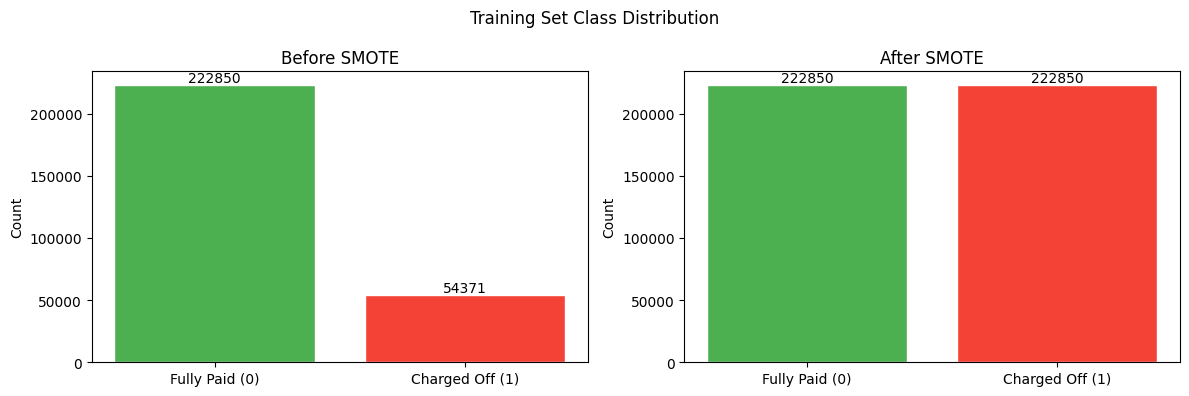

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, counts, title in zip(axes,
    [Counter(y_train), Counter(y_train_sm)],
    ['Before SMOTE', 'After SMOTE']):
    bars = ax.bar(['Fully Paid (0)', 'Charged Off (1)'],
                  [counts[0], counts[1]],
                  color=['#4CAF50', '#F44336'], edgecolor='white')
    ax.bar_label(bars, fmt='%d')
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.suptitle('Training Set Class Distribution', fontsize=12)
plt.tight_layout()
plt.show()

---
## Section 14: Logistic Regression with SMOTE

In [40]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_sm, y_train_sm)

# Evaluate on original unbalanced test set
y_pred_sm = lr_smote.predict(X_test_scaled)
y_prob_sm = lr_smote.predict_proba(X_test_scaled)[:, 1]

print("=" * 55)
print("  LOGISTIC REGRESSION WITH SMOTE")
print("=" * 55)
print(f"\nAccuracy: {(y_pred_sm == y_test).mean():.4f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, y_prob_sm):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_sm,
                             target_names=['Fully Paid (0)', 'Charged Off (1)']))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_sm))

  LOGISTIC REGRESSION WITH SMOTE

Accuracy: 0.6617
ROC-AUC:  0.7094

Classification Report:
                 precision    recall  f1-score   support

 Fully Paid (0)       0.88      0.67      0.76     95507
Charged Off (1)       0.32      0.64      0.43     23302

       accuracy                           0.66    118809
      macro avg       0.60      0.65      0.59    118809
   weighted avg       0.77      0.66      0.69    118809

Confusion Matrix:
[[63647 31860]
 [ 8333 14969]]


### Baseline vs SMOTE — Side-by-Side Comparison

| Metric | Baseline (No SMOTE) | With SMOTE |
|---|---|---|
| Accuracy | ~80% | ~66% |
| ROC-AUC | ~0.71 | ~0.71 |
| Charged Off Recall | ~8% | ~64% |
| Charged Off Precision | ~52% | ~32% |
| Charged Off F1 | ~0.14 | ~0.42 |

**Key insight:** SMOTE dramatically improves Recall for the Charged Off class — from ~8% to ~64%. That is an 8× improvement in catching actual defaulters. The tradeoff is lower accuracy (~66%) because the model now flags more good borrowers as risky.

**ROC-AUC stays at ~0.71** — SMOTE improved the operating point (where the model makes decisions), not the fundamental discriminative ability of Logistic Regression on this dataset.

---
## Section 15: Model Evaluation

### 15.1 ROC Curve and Precision-Recall Curve

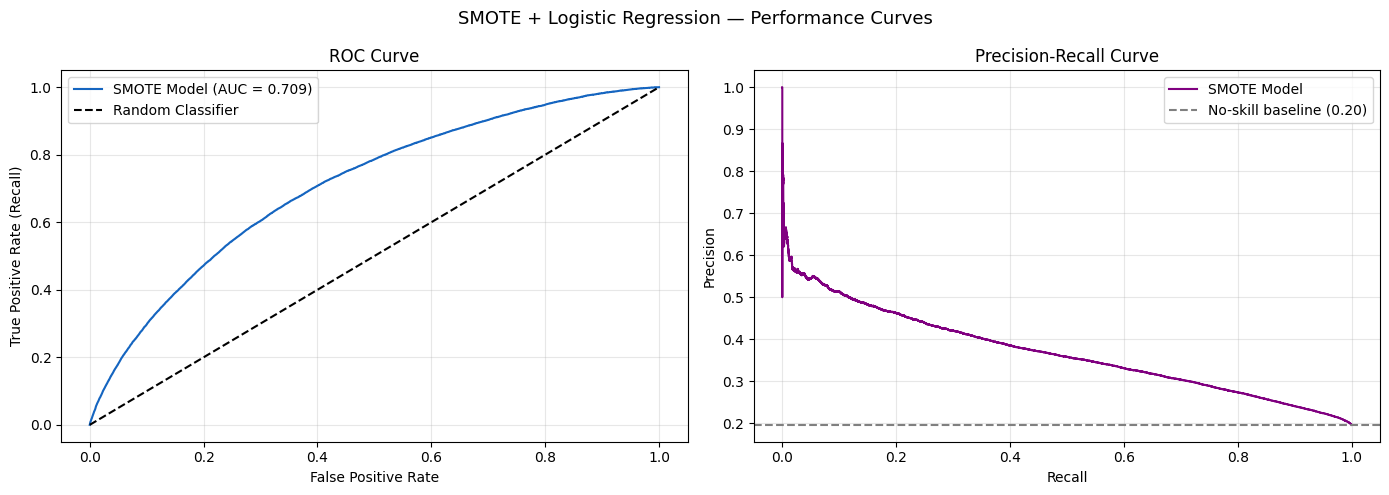

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_sm)
ax1.plot(fpr, tpr, color='#1565C0',
         label=f'SMOTE Model (AUC = {roc_auc_score(y_test, y_prob_sm):.3f})')
ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate (Recall)')
ax1.set_title('ROC Curve')
ax1.legend()
ax1.grid(alpha=0.3)

# Precision-Recall Curve
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_sm)
ax2.plot(recall_curve, precision_curve, color='purple', label='SMOTE Model')
ax2.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f'No-skill baseline ({y_test.mean():.2f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('SMOTE + Logistic Regression — Performance Curves', fontsize=13)
plt.tight_layout()
plt.show()

### 15.2 Confusion Matrix

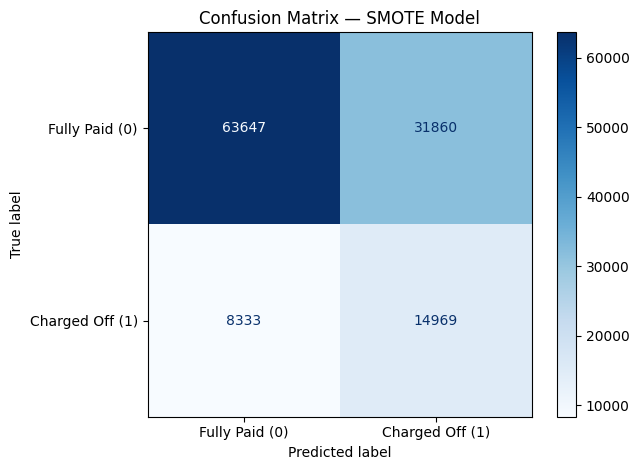

True Negatives  (Fully Paid, correctly identified):  63,647
False Positives (Fully Paid, flagged as Charged Off): 31,860
False Negatives (Charged Off, missed by model):       8,333
True Positives  (Charged Off, correctly caught):      14,969


In [42]:
ConfusionMatrixDisplay.from_estimator(
    lr_smote, X_test_scaled, y_test,
    display_labels=['Fully Paid (0)', 'Charged Off (1)'],
    cmap='Blues'
)
plt.title('Confusion Matrix — SMOTE Model')
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, y_pred_sm)
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Fully Paid, correctly identified):  {tn:,}")
print(f"False Positives (Fully Paid, flagged as Charged Off): {fp:,}")
print(f"False Negatives (Charged Off, missed by model):       {fn:,}")
print(f"True Positives  (Charged Off, correctly caught):      {tp:,}")

---
## Section 16: Threshold Analysis

By default, a borrower is classified as Charged Off when predicted probability ≥ 0.5. We can change this threshold.

| Threshold | Effect |
|---|---|
| Lower (e.g., 0.3) | More borrowers flagged as risky → higher Recall, lower Precision |
| Higher (e.g., 0.7) | Stricter → higher Precision, lower Recall |

The right threshold depends on LoanTap's business judgment: how costly is a missed defaulter (NPA) vs a wrongly rejected good borrower (lost interest revenue)?

In [43]:
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
results = []

for t in thresholds:
    y_pred_t = (y_prob_sm >= t).astype(int)
    results.append({
        'Threshold':      t,
        'Precision (1)':  round(precision_score(y_test, y_pred_t, zero_division=0), 4),
        'Recall (1)':     round(recall_score(y_test, y_pred_t, zero_division=0), 4),
        'F1-Score (1)':   round(f1_score(y_test, y_pred_t, zero_division=0), 4),
        'Accuracy':       round((y_pred_t == y_test).mean(), 4)
    })

threshold_df = pd.DataFrame(results)
print("Threshold Analysis (all metrics for Charged Off class = 1):")
display(threshold_df)

Threshold Analysis (all metrics for Charged Off class = 1):


,Threshold,Precision (1),Recall (1),F1-Score (1),Accuracy
0,0.2,0.2065,0.9884,0.3416,0.2526
1,0.3,0.2311,0.9302,0.3702,0.3792
2,0.4,0.2699,0.8130,0.4052,0.5319
3,0.5,0.3197,0.6424,0.4269,0.6617
4,0.6,0.3740,0.4380,0.4035,0.7460
5,0.7,0.4360,0.2542,0.3212,0.7892
6,0.8,0.5126,0.1012,0.1690,0.8048


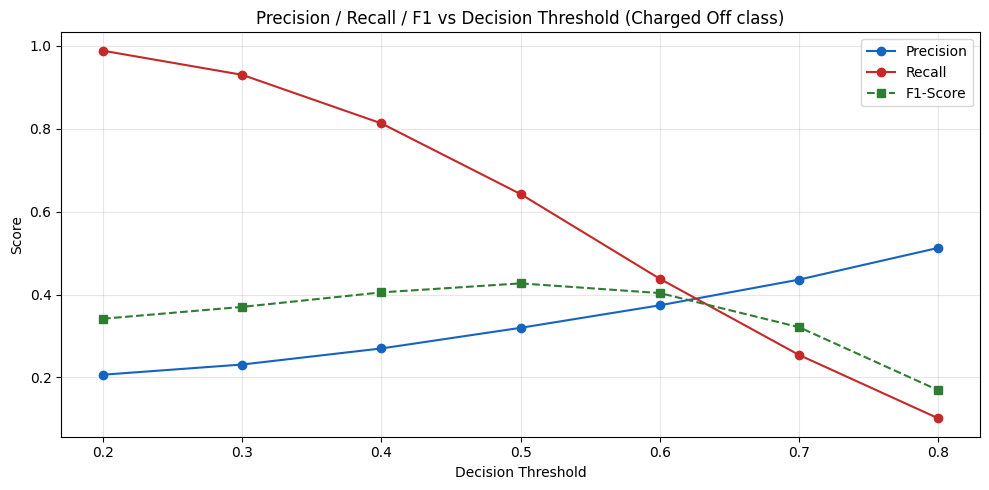

In [44]:
plt.figure(figsize=(10, 5))
plt.plot(threshold_df['Threshold'], threshold_df['Precision (1)'],
         label='Precision', marker='o', color='#1565C0')
plt.plot(threshold_df['Threshold'], threshold_df['Recall (1)'],
         label='Recall', marker='o', color='#C62828')
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score (1)'],
         label='F1-Score', marker='s', linestyle='--', color='#2E7D32')
plt.xlabel('Decision Threshold')
plt.ylabel('Score')
plt.title('Precision / Recall / F1 vs Decision Threshold (Charged Off class)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Threshold Recommendation:**

For LoanTap, a threshold around **0.3–0.4** is likely appropriate:
- NPA loss per defaulter > revenue lost per rejected good borrower
- So we accept more false positives (wrongly rejected good borrowers) to catch more real defaulters
- The exact optimal threshold should be determined by LoanTap's cost-benefit analysis

---
## Section 17: Logistic Regression Coefficients

Since features are standardised, we can compare coefficient magnitudes directly.

- **Positive coefficient** → higher feature value → higher probability of Charged Off (1)
- **Negative coefficient** → higher feature value → lower probability of default

> Coefficients show association, not causation.

In [45]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_smote.coef_[0]
})
coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False).reset_index(drop=True)

print("Coefficients (ranked by absolute impact):")
display(coef_df)

Coefficients (ranked by absolute impact):


,Feature,Coefficient,Abs_Coefficient
0,sub_grade,0.479996,0.479996
1,annual_inc,-0.274099,0.274099
2,term,0.189113,0.189113
3,dti,0.183263,0.183263
4,revol_util,0.145585,0.145585
5,installment,0.124940,0.124940
6,pub_rec_flag,0.088861,0.088861
7,mort_acc_flag,-0.084387,0.084387
8,revol_bal,-0.083861,0.083861
9,open_acc,0.076405,0.076405


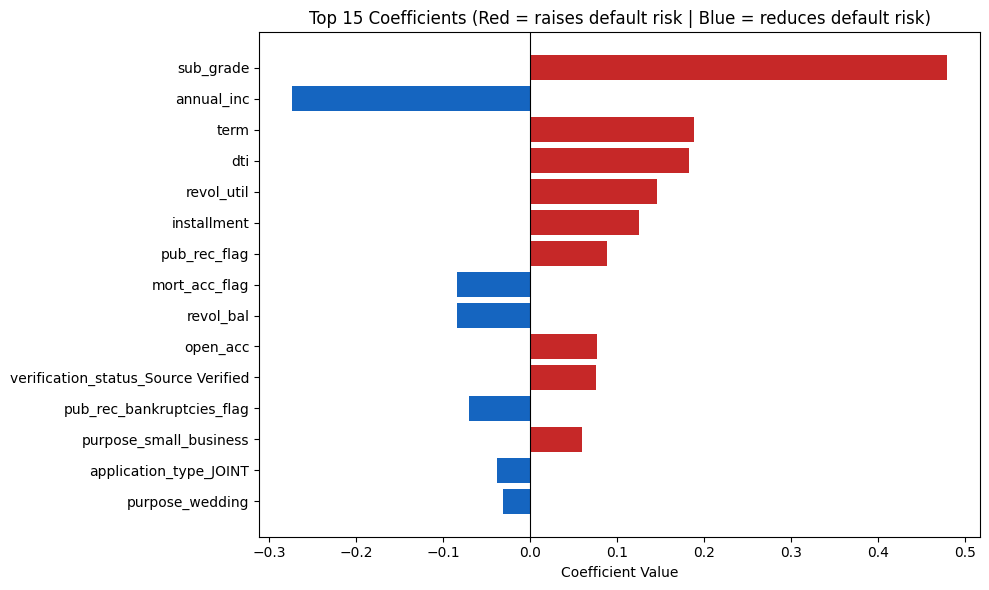

In [46]:
# Visualize top 15 features
top15 = coef_df.head(15).copy()
colors = ['#C62828' if c > 0 else '#1565C0' for c in top15['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(top15['Feature'][::-1], top15['Coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Coefficients (Red = raises default risk | Blue = reduces default risk)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

**Key Feature Insights:**

**Associated with HIGHER default risk (positive):**
- `sub_grade` — Higher grade number = worse credit → strongest predictor
- `dti` — Higher debt-to-income → borrower more financially stretched
- `revol_util` — High credit utilisation → near credit limit → risk signal
- `pub_rec_flag` / `pub_rec_bankruptcies_flag` — Any derogatory record is a strong warning
- `term` — 60-month loans carry more default risk than 36-month loans

**Associated with LOWER default risk (negative):**
- `annual_inc` — Higher income → more repayment capacity
- `credit_age_years` — Longer credit history → more financial experience
- `mort_acc_flag` — Managing a mortgage shows creditworthiness

---
## Section 18: Business Recommendations

### 18.1 Model Summary

| Metric | Baseline (No SMOTE) | Recommended (SMOTE) |
|---|---|---|
| Accuracy | ~80% | ~66% |
| ROC-AUC | ~0.71 | ~0.71 |
| Charged Off Recall | ~8% | ~64% |
| Charged Off Precision | ~52% | ~32% |
| Charged Off F1 | ~0.14 | ~0.42 |

The SMOTE model is strongly preferred — detecting 64% of real defaulters vs 8% is an 8× improvement.

---

### 18.2 The Core Business Tradeoff

| Error Type | What Happens | Cost |
|---|---|---|
| **False Negative** (missed defaulter) | Loan disbursed, borrower defaults | Full principal loss → NPA |
| **False Positive** (good borrower rejected) | Loan denied | Foregone interest revenue |

Since NPA losses per event typically exceed lost-revenue costs, **Recall is the primary metric** for LoanTap — not accuracy.

---

### 18.3 Recommendations

1. **Use the SMOTE model** as the primary underwriting screen
2. **Set the decision threshold at 0.3–0.4** (instead of default 0.5) to improve recall and reduce NPAs
3. **High-risk signals to watch:**
   - Sub-grade D–G → apply stricter scrutiny
   - DTI above the upper whisker → mandatory income verification
   - Revolving utilisation > 70% → flag for additional review
   - Any public record / bankruptcy → enhanced due diligence
4. **Do not use accuracy as the primary metric** — it is misleading on imbalanced data
5. **Use this model as a first-tier screen** — borderline cases (probability 0.4–0.6) should go to manual review

---

### 18.4 Limitations

- ROC-AUC = ~0.71 is moderate. Logistic Regression has linear decision boundaries and may miss complex patterns
- The model lacks credit bureau scores, real-time income verification, and payment history
- Geographic features were dropped due to PII — regional economic factors are not captured
- Retraining is needed as new loan performance data accumulates

---

*LoanTap Personal Loan Credit Risk — Logistic Regression Business Case | Vishwash Patidar*